In [1]:
import requests
import numpy as np
import matplotlib.pyplot as plt

# URL of your FastAPI endpoint

# Path to the image you want to upload
image_path = '/home/MultiModalCoreset/fastapi/test_imgs/rgb.png'


In [2]:
(image_path.split('/')[-1], open(image_path, 'rb'), 'image/jpeg')

('rgb.png',
 <_io.BufferedReader name='/home/MultiModalCoreset/fastapi/test_imgs/rgb.png'>,
 'image/jpeg')

In [19]:

# The name 'file' corresponds to the name of the parameter in your FastAPI endpoint.
# If your endpoint expects a different parameter name, change it accordingly.
files = {'file': (image_path.split('/')[-1], open(image_path, 'rb'), 'image/jpeg')}


In [22]:
files = {'file': open(image_path, 'rb')}

In [23]:
url = 'http://127.0.0.1:8886/uploadimage/'
# Make a POST request to the endpoint
response = requests.post(url, files=files)


In [24]:
response.json()

{'filename': 'rgb.png', 'format': 'PNG', 'size': [512, 512]}

In [26]:

# Check the response
print(f'Status Code: {response.status_code}')
print('Response Body:', response.json())

# Don't forget to close the file
files['file'].close()


Status Code: 200
Response Body: {'filename': 'rgb.png', 'format': 'PNG', 'size': [512, 512]}


In [68]:
rgb_path = '/home/MultiModalCoreset/fastapi/test_imgs/rgb.png'
semseg_path = '/home/MultiModalCoreset/fastapi/test_imgs/semseg.png'
inputs = {'rgb': open(rgb_path, 'rb'),
          'semseg': open(semseg_path, 'rb')
}
files = {'rgb': open(rgb_path, 'rb'), 'semseg': open(semseg_path, 'rb')}
url = 'http://127.0.0.1:8886/upload_two_image/'
response = requests.get(url, files=inputs)


In [71]:
files['rgb'].close()
files['semseg'].close()

In [70]:

print(f'Status Code: {response.status_code}')
print('Response Body:', response.json())

Status Code: 200
Response Body: {'filename': 'rgb.png', 'format': None, 'size': [512, 512], 'rgb_max': 255, 'sformat': 'PNG', 'ssize': [512, 512]}


In [29]:
inputs['rgb'].close()
inputs['semseg'].close()

In [10]:
response

<Response [500]>

In [52]:
m = np.random.randint(0, 255, size=[3, 512, 512]).astype(np.uint8)

In [53]:
m.max()

254

In [54]:
print(m)

[[[ 21 201  53 ... 193  89 107]
  [176 194 129 ... 168 186 191]
  [ 57 232 114 ... 217  12 124]
  ...
  [ 77  25 143 ... 153 151  99]
  [110 223  70 ...  63 145  10]
  [231 153 192 ...  44 110 183]]

 [[254 126  86 ...  74 129  76]
  [ 25 181  25 ...   3 113 236]
  [234  42 231 ... 171 132 172]
  ...
  [  1   3 249 ...  97  92 242]
  [204 149  65 ... 243 163 212]
  [162 179 182 ...  68 129  22]]

 [[194 250 223 ... 224  25 212]
  [ 61 144  48 ... 101  59 137]
  [ 79  82  96 ...  96 204  53]
  ...
  [175  89 117 ...  34   3  24]
  [160 106 135 ...   6 105 158]
  [225 194 127 ... 254 168 168]]]


In [61]:
from model_utils import init_rgb_model, init_semseg_model, init_rgb_semseg_model, inference, semseg_inference, multi_inference

In [62]:
model = init_rgb_model()
semseg = init_semseg_model()
multimodel = init_rgb_semseg_model()

<All keys matched successfully>


/usr/local/lib/python3.10/dist-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


<All keys matched successfully>
<All keys matched successfully>


In [64]:
from PIL import Image

img = Image.open('/home/data/dq/clevr_complex/train/rgb/1002_0.png').convert('RGB')
semantic = Image.open('/home/data/dq/clevr_complex/train/semseg/1002_0.png').convert('L')
depth = Image.open('/home/data/dq/clevr_complex/train/depth/1002_0.png')

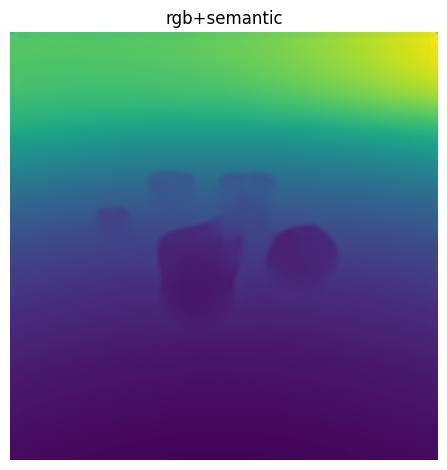

In [67]:

multi_out = multi_inference(img, semantic, multimodel)
plt.imshow(multi_out)
plt.axis('off')
plt.title('rgb+semantic')
plt.tight_layout()

In [2]:
rgb_path = '/home/MultiModalCoreset/fastapi/test_imgs/rgb.png'
semseg_path = '/home/MultiModalCoreset/fastapi/test_imgs/semseg.png'
files = {'rgb': open(rgb_path, 'rb')}
url = 'http://127.0.0.1:8886/rgb_inference/'
response = requests.get(url, files=files)

files['rgb'].close()


In [3]:

print(f'Status Code: {response.status_code}')
print('Response Body:', response.json())

Status Code: 200
Response Body: {'prediction': [[22266.931640625, 24859.884765625, 25010.15625, 25086.890625, 24722.095703125, 24632.59765625, 24581.630859375, 24523.220703125, 24433.205078125, 24488.82421875, 24544.619140625, 24534.375, 24506.634765625, 24500.15625, 24504.552734375, 24498.775390625, 24498.57421875, 24510.025390625, 24520.806640625, 24527.115234375, 24527.42578125, 24525.357421875, 24518.537109375, 24522.46484375, 24520.87890625, 24506.8671875, 24489.837890625, 24474.412109375, 24462.23046875, 24445.8671875, 24430.697265625, 24404.90234375, 24384.115234375, 24381.15625, 24386.4765625, 24393.275390625, 24399.689453125, 24406.130859375, 24410.078125, 24424.05859375, 24434.869140625, 24435.294921875, 24431.541015625, 24427.560546875, 24425.623046875, 24420.205078125, 24414.80859375, 24399.41015625, 24385.998046875, 24386.146484375, 24394.126953125, 24404.908203125, 24415.71484375, 24426.416015625, 24434.875, 24451.470703125, 24466.10546875, 24472.06640625, 24472.908203125

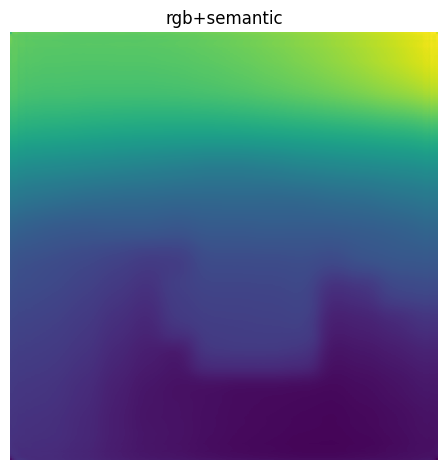

In [6]:
pred = np.array(response.json()['prediction'])
plt.imshow(pred)
plt.axis('off')
plt.title('rgb+semantic')
plt.tight_layout()

In [18]:
rgb_path = '/home/MultiModalCoreset/fastapi/test_imgs/rgb.png'
semseg_path = '/home/MultiModalCoreset/fastapi/test_imgs/semseg.png'
files = {'rgb': open(rgb_path, 'rb'), 'semseg': open(semseg_path, 'rb')}
url = 'http://127.0.0.1:8886/rgb_semantic_inference/'
response = requests.get(url, files=files)

files['rgb'].close()
files['semseg'].close()



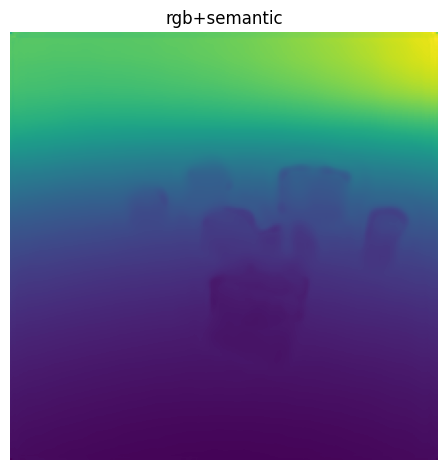

In [19]:
pred = np.array(response.json()['prediction'])
plt.imshow(pred)
plt.axis('off')
plt.title('rgb+semantic')
plt.tight_layout()

In [13]:
rgb_path = '/home/MultiModalCoreset/fastapi/test_imgs/rgb.png'
semseg_path = '/home/MultiModalCoreset/fastapi/test_imgs/semseg.png'
files = {'semseg': open(semseg_path, 'rb')}
url = 'http://127.0.0.1:8886/semantic_inference/'
response = requests.get(url, files=files)

files['semseg'].close()



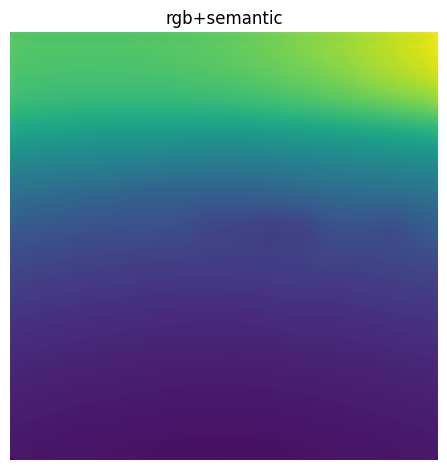

In [15]:
pred = np.array(response.json()['prediction'])
plt.imshow(pred)
plt.axis('off')
plt.title('rgb+semantic')
plt.tight_layout()

In [27]:
files_and_data = []
for i, path in enumerate(rgb_paths):
    files_and_data.append(('rgb_ls', (f'rgb_image{i}.jpg', open(path, 'rb'), 'image/jpeg')))
for i, path in enumerate(depth_paths):
    files_and_data.append(('depth_ls', (f'depth_image{i}.jpg', open(path, 'rb'), 'image/jpeg')))

# Add the 'token' as part of the data to be sent
# Note: As per `requests` documentation, data and files can be combined in multipart/form-data requests
data = {'token': 'my_token'}

# Make a POST request to the endpoint
response = requests.post(url, files=files_and_data, data=data)

In [29]:
response.json()

{'message': 'RGB Model successfully fine-tuned',
 'losses': [20518.310546875, 19523.927734375]}

In [30]:
for _, file_tuple in files_and_data:
    if isinstance(file_tuple, tuple):  # Only file objects have a tuple
        file_tuple[1].close()